# Algorithmic Stock Breakout & Fakeout Detection

### Project Overview
This notebook implements an end-to-end algorithmic pipeline to detect and analyze **price breakouts** and differentiate them from **fakeouts** (bull traps) using technical price action, volume confirmation, and forward-looking validation.

---

## 1. Environment Setup & Data Ingestion

### 1.1 Install Dependencies
Install the required third-party libraries:
- `yfinance`: To query and retrieve historical market OHLCV data from Yahoo Finance.
- `pandas`: For time-series data structures, rolling window calculations, and tabular manipulation.


In [1]:
!pip install yfinance pandas

### 1.2 Import Required Libraries
Import standard and third-party modules:
- `yfinance`: Market data retrieval interface.
- `pandas`: DataFrames, series calculations, and CSV operations.
- `os`: Operating system interface for directory and file path management.


In [2]:
import yfinance as yf
import pandas as pd
import os

### 1.3 Configuration: Target Equities & Historical Window
Define the target universe of **50 large-cap US equities** across key sectors:
- **Technology & Semis (15)**: AAPL, MSFT, NVDA, GOOGL, AMZN, META, TSLA, AMD, INTC, QCOM, AVGO, CSCO, ORCL, CRM, ADBE.
- **Financials (6)**: JPM, BAC, WFC, GS, MS, V, MA.
- **Consumer & Retail (9)**: WMT, COST, PG, KO, PEP, HD, MCD, NKE, DIS.
- **Healthcare & Pharma (6)**: JNJ, UNH, LLY, ABBV, PFE, MRK, TMO.
- **Energy & Industrials (8)**: XOM, CVX, COP, SLB, CAT, BA, GE, HON, UNP.
- **Communication (3)**: NFLX, CMCSA, VZ.
- **Time Range**: Daily historical data starting from `2000-01-01` through the latest available trading date (`end_date = None`).

In [3]:
tickers = [
    # Original Large-Cap Tech & Core (10)
    "AAPL", "MSFT", "AMZN", "GOOGL", "NVDA", "TSLA", "META", "JPM", "XOM", "JNJ",
    # Tech & Semis (8)
    "AMD", "INTC", "QCOM", "AVGO", "CSCO", "ORCL", "CRM", "ADBE",
    # Financials (6)
    "BAC", "WFC", "GS", "MS", "V", "MA",
    # Consumer & Retail (9)
    "WMT", "COST", "PG", "KO", "PEP", "HD", "MCD", "NKE", "DIS",
    # Healthcare & Pharma (6)
    "UNH", "LLY", "ABBV", "PFE", "MRK", "TMO",
    # Energy & Industrials (8)
    "CVX", "COP", "SLB", "CAT", "BA", "GE", "HON", "UNP",
    # Communication (3)
    "NFLX", "CMCSA", "VZ"
]

start_date = "2000-01-01"
end_date = None  # None = up to latest available date
print(f"Configured Universe: {len(tickers)} liquid US equities")

Configured Universe: 50 liquid US equities


### 1.4 Create Local Storage Directory
Ensure the local folder `stock_data/` exists to cache downloaded ticker datasets as CSV files. Setting `exist_ok=True` prevents exceptions if the folder already exists.


In [4]:
os.makedirs("stock_data", exist_ok=True)

### 1.5 Download and Store Historical Stock Data
Iterate through the ticker list to:
1. Fetch daily adjusted historical OHLCV data using `yf.download`.
2. Remove null/missing values (`dropna()`).
3. Flatten column levels if MultiIndex headers are returned.
4. Save each equity's time series to `stock_data/{ticker}.csv`.


In [5]:
for ticker in tickers:
    filepath = f"stock_data/{ticker}.csv"
    if os.path.exists(filepath):
        continue
        
    print(f"Downloading {ticker}...")
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=True,
        progress=False
    )
    df = df.dropna().reset_index()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.to_csv(filepath, index=False)
    print(f"{ticker}: {len(df)} rows saved → {filepath}")

print(f"All {len(tickers)} equities verified and available in stock_data/")

All 50 equities verified and available in stock_data/


## 2. Data Loading & Verification

### 2.1 Inspect Sample Dataset (Apple Inc. - AAPL)
Load the saved `AAPL.csv` file into a DataFrame to inspect initial rows, column formatting (Date, Open, High, Low, Close, Volume), and verify data cleanliness.


In [6]:
aapl = pd.read_csv("stock_data/AAPL.csv")

aapl.head()

,Date,Close,High,Low,Open,Volume
0,2000-01-03,0.837002,0.841208,0.760359,0.784193,535796800
1,2000-01-04,0.766435,0.827188,0.756620,0.809429,512377600
2,2000-01-05,0.777650,0.826721,0.770173,0.775781,778321600
3,2000-01-06,0.710353,0.800082,0.710353,0.793540,767972800
4,2000-01-07,0.744002,0.755218,0.714093,0.721570,460734400


### 2.2 Verify Downloaded Datasets Across All Tickers
Iterate through all downloaded CSV files to verify their date ranges (earliest date to latest date) and total record counts, confirming that all assets were downloaded correctly without missing files or corruption.


In [7]:
for ticker in tickers:
    df = pd.read_csv(f"stock_data/{ticker}.csv")
    
    print(
        f"{ticker}: "
        f"{df['Date'].min()} → {df['Date'].max()} | "
        f"{len(df)} rows"
    )

AAPL: 2000-01-03 → 2026-09-08 | 6710 rows
MSFT: 2000-01-03 → 2026-09-08 | 6710 rows
AMZN: 2000-01-03 → 2026-09-08 | 6710 rows
GOOGL: 2004-08-19 → 2026-09-08 | 5548 rows
NVDA: 2000-01-03 → 2026-09-08 | 6710 rows
TSLA: 2010-06-29 → 2026-09-08 | 4073 rows
META: 2012-05-18 → 2026-09-08 | 3596 rows
JPM: 2000-01-03 → 2026-09-08 | 6710 rows
XOM: 2000-01-03 → 2026-09-08 | 6710 rows
JNJ: 2000-01-03 → 2026-09-08 | 6710 rows
AMD: 2000-01-03 → 2026-09-08 | 6710 rows
INTC: 2000-01-03 → 2026-09-08 | 6710 rows
QCOM: 2000-01-03 → 2026-09-08 | 6710 rows
AVGO: 2009-08-06 → 2026-09-08 | 4298 rows
CSCO: 2000-01-03 → 2026-09-08 | 6710 rows
ORCL: 2000-01-03 → 2026-09-08 | 6710 rows
CRM: 2004-06-23 → 2026-09-08 | 5588 rows
ADBE: 2000-01-03 → 2026-09-08 | 6710 rows
BAC: 2000-01-03 → 2026-09-08 | 6710 rows
WFC: 2000-01-03 → 2026-09-08 | 6710 rows
GS: 2000-01-03 → 2026-09-08 | 6710 rows
MS: 2000-01-03 → 2026-09-08 | 6710 rows


V: 2008-03-19 → 2026-09-08 | 4647 rows


MA: 2006-05-25 → 2026-09-08 | 5103 rows
WMT: 2000-01-03 → 2026-09-08 | 6710 rows
COST: 2000-01-03 → 2026-09-08 | 6710 rows
PG: 2000-01-03 → 2026-09-08 | 6710 rows


KO: 2000-01-03 → 2026-09-08 | 6710 rows
PEP: 2000-01-03 → 2026-09-08 | 6710 rows
HD: 2000-01-03 → 2026-09-08 | 6710 rows
MCD: 2000-01-03 → 2026-09-08 | 6710 rows
NKE: 2000-01-03 → 2026-09-08 | 6710 rows
DIS: 2000-01-03 → 2026-09-08 | 6710 rows
UNH: 2000-01-03 → 2026-09-08 | 6710 rows
LLY: 2000-01-03 → 2026-09-08 | 6710 rows
ABBV: 2013-01-02 → 2026-09-08 | 3441 rows
PFE: 2000-01-03 → 2026-09-08 | 6710 rows
MRK: 2000-01-03 → 2026-09-08 | 6710 rows
TMO: 2000-01-03 → 2026-09-08 | 6710 rows
CVX: 2000-01-03 → 2026-09-08 | 6710 rows
COP: 2000-01-03 → 2026-09-08 | 6710 rows
SLB: 2000-01-03 → 2026-09-08 | 6710 rows
CAT: 2000-01-03 → 2026-09-08 | 6710 rows
BA: 2000-01-03 → 2026-09-08 | 6710 rows
GE: 2000-01-03 → 2026-09-08 | 6710 rows
HON: 2000-01-03 → 2026-09-08 | 6710 rows
UNP: 2000-01-03 → 2026-09-08 | 6710 rows
NFLX: 2002-05-23 → 2026-09-08 | 6112 rows


CMCSA: 2000-01-03 → 2026-09-08 | 6710 rows
VZ: 2000-01-03 → 2026-09-08 | 6710 rows


## 3. Strategy Parameters & Baseline Configuration

### 3.1 Parameter Definitions & Rolling Windows
Define the quantitative strategy hyperparameters:
- **`LOOKBACK = 30`**: A 30-day rolling window (~1.5 trading months / 6 weeks) establishing the historical resistance ceiling and average volume.
- **`CONFIRMATION_DAYS = 5`**: A 5-day forward horizon (~1 trading week) to confirm breakout sustainability.
- **`HORIZON_30D = 30`**: A 30-day forward horizon (~1.5 trading months) to evaluate medium-term trend continuation and maximum upside/downside excursion.
- **`BREAKOUT_PCT = 0.01`**: Minimum price clearance of 1% above the 30-day resistance.
- **`CLOSE_NEAR_HIGH = 0.70`**: Bullish candle quality threshold (close in top 30% of day's range).
- **`VOLUME_MULTIPLIER = 1.20`**: Institutional volume expansion ($\ge 120\%$ of 30-day average volume).


In [8]:
LOOKBACK = 30
CONFIRMATION_DAYS = 5
HORIZON_30D = 30

BREAKOUT_PCT = 0.01       # 1% clearance above resistance
CLOSE_NEAR_HIGH = 0.70    # Close must be in top 30% of day's candle
VOLUME_MULTIPLIER = 1.20  # Volume >= 120% of 30-day average

print(f"Baseline Parameters: Lookback={LOOKBACK}d | Confirmation={CONFIRMATION_DAYS}d | Long-term Horizon={HORIZON_30D}d")


Baseline Parameters: Lookback=30d | Confirmation=5d | Long-term Horizon=30d


## 4. Multi-Asset Pipeline & Unified Dataset Construction

### 4.1 Processing Loop Across 50 Equities
Iterate across all 50 stock datasets to:
1. Compute technical indicators without lookahead bias:
   - **`Resistance`**: 30-day rolling High, shifted by 1 (`shift(1)`).
   - **`Avg_Volume_30`**: 30-day rolling mean Volume, shifted by 1.
   - **`Close_Position`**: Intraday closing strength $\frac{\text{Close} - \text{Low}}{\text{High} - \text{Low}}$.
   - **`Volume_Ratio`**: Relative volume surge $\frac{\text{Volume}}{\text{Avg\_Volume\_30}}$.
2. Identify **Breakout Candidates** satisfying all 3 screening criteria.
3. Compute the **Clean Binary Ground-Truth Label**:
   - **`breakout` (1)**: $\ge 4$ days closing above resistance AND 5-day average close above resistance.
   - **`fakeout` (0)**: $\ge 3$ days closing below resistance AND 5-day average close below resistance.
   - **Ambiguous Neutral/Retest Events**: Excluded from the dataset to eliminate high-noise boundary cases.
4. Track **30-Day Forward Continuation Metrics** (strictly quarantined from training):
   - **`Return_30d_%`**: Percentage return from breakout day to day +30.
   - **`Max_Gain_30d_%`**: Peak price reach over 30 days.
   - **`Max_Drawdown_30d_%`**: Deepest pullback over 30 days.
   - **`Pct_Days_Above_30d`**: Percentage of the 30 days spent above resistance.
   - **`Continued_Up_30d`**: Volatility-adjusted hurdle indicator whether 30-day return exceeded 1 ATR unit (`Return_30d_% > ATR_Pct`).

In [9]:
import numpy as np
import os

all_records = []
os.makedirs("data", exist_ok=True)
neutral_count = 0

for ticker in tickers:
    filepath = f"stock_data/{ticker}.csv"
    if not os.path.exists(filepath):
        continue
        
    df_stock = pd.read_csv(filepath)
    df_stock["Date"] = pd.to_datetime(df_stock["Date"])
    df_stock = df_stock.sort_values("Date").reset_index(drop=True)
    
    if len(df_stock) < LOOKBACK + HORIZON_30D + 10:
        continue
    
    # Prior return
    df_stock["Return"] = df_stock["Close"].pct_change()
    
    # 1. Moving Averages & Distances (Shift 1)
    df_stock["MA_10"] = df_stock["Close"].shift(1).rolling(10).mean()
    df_stock["MA_30"] = df_stock["Close"].shift(1).rolling(30).mean()
    df_stock["MA_Ratio"] = df_stock["MA_10"] / (df_stock["MA_30"] + 1e-9)
    df_stock["Distance_MA10_%"] = ((df_stock["Close"] - df_stock["MA_10"]) / (df_stock["MA_10"] + 1e-9)) * 100
    df_stock["Distance_MA30_%"] = ((df_stock["Close"] - df_stock["MA_30"]) / (df_stock["MA_30"] + 1e-9)) * 100
    
    # 2. Volume Metrics
    df_stock["Avg_Volume_30"] = df_stock["Volume"].shift(1).rolling(30).mean()
    df_stock["Avg_Volume_10"] = df_stock["Volume"].shift(1).rolling(10).mean()
    df_stock["Volume_Ratio"] = df_stock["Volume"] / (df_stock["Avg_Volume_30"] + 1e-9)
    df_stock["Volume_Surge_10"] = df_stock["Volume"] / (df_stock["Avg_Volume_10"] + 1e-9)
    
    # 3. Momentum Metrics
    df_stock["Momentum_5d_%"] = ((df_stock["Close"] / df_stock["Close"].shift(5)) - 1) * 100
    df_stock["Momentum_10d_%"] = ((df_stock["Close"] / df_stock["Close"].shift(10)) - 1) * 100
    df_stock["Momentum_20d_%"] = ((df_stock["Close"] / df_stock["Close"].shift(20)) - 1) * 100
    
    # 4. Volatility & Range Metrics
    high_low = df_stock["High"] - df_stock["Low"]
    high_close = (df_stock["High"] - df_stock["Close"].shift(1)).abs()
    low_close = (df_stock["Low"] - df_stock["Close"].shift(1)).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df_stock["ATR_14"] = tr.rolling(14).mean()
    df_stock["ATR_Pct"] = (df_stock["ATR_14"] / (df_stock["Close"] + 1e-9)) * 100
    
    df_stock["Daily_Range_%"] = (high_low) / (df_stock["Close"] + 1e-9) * 100
    df_stock["Avg_Range_10"] = df_stock["Daily_Range_%"].shift(1).rolling(10).mean()
    df_stock["Range_Ratio"] = df_stock["Daily_Range_%"] / (df_stock["Avg_Range_10"] + 1e-9)
    
    df_stock["Volatility_10d"] = df_stock["Return"].shift(1).rolling(10).std()
    df_stock["Price_Range_10d_%"] = ((df_stock["High"].shift(1).rolling(10).max() - df_stock["Low"].shift(1).rolling(10).min()) / (df_stock["Close"] + 1e-9)) * 100
    
    # 5. RSI 14
    delta = df_stock["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(14).mean() / (loss.rolling(14).mean() + 1e-9)
    df_stock["RSI_14"] = 100 - (100 / (1 + rs))
    
    # 6. Resistance & Screening Conditions
    df_stock["Resistance"] = df_stock["High"].shift(1).rolling(LOOKBACK).max()
    df_stock["Resistance_Distance_%"] = ((df_stock["Close"] - df_stock["Resistance"]) / (df_stock["Resistance"] + 1e-9)) * 100
    df_stock["Breakout_Pct"] = df_stock["Resistance_Distance_%"]
    df_stock["Close_Position"] = np.where(high_low > 0, (df_stock["Close"] - df_stock["Low"]) / high_low, 0)
    
    df_stock["Breakout_Candidate"] = (
        (df_stock["Close"] > df_stock["Resistance"] * (1 + BREAKOUT_PCT)) &
        (df_stock["Close_Position"] >= CLOSE_NEAR_HIGH) &
        (df_stock["Volume_Ratio"] >= VOLUME_MULTIPLIER)
    )
    
    # 7. Candidate Loop
    for i in range(LOOKBACK, len(df_stock) - HORIZON_30D):
        if not df_stock.loc[i, "Breakout_Candidate"]:
            continue
            
        res = df_stock.loc[i, "Resistance"]
        breakout_close = df_stock.loc[i, "Close"]
        
        # 5-Day Confirmation Window (Positional Window)
        fut_5d_window = df_stock.iloc[i + 1 : i + 1 + CONFIRMATION_DAYS]
        fut_5d = fut_5d_window["Close"]
        days_above_5d = (fut_5d >= res).sum()
        days_below_5d = CONFIRMATION_DAYS - days_above_5d
        avg_5d_close = fut_5d.mean()
        
        # Clean Binary Labeling
        if days_above_5d >= 4 and avg_5d_close > res:
            label = "breakout"
        elif days_below_5d >= 3 and avg_5d_close < res:
            label = "fakeout"
        else:
            neutral_count += 1
            continue  # Filter out ambiguous noise
            
        ret_5d = (fut_5d.iloc[-1] - breakout_close) / breakout_close * 100
        
        # 30-Day Forward Continuation Window (Full High/Low Intraday Excursion)
        fut_30d_window = df_stock.iloc[i + 1 : i + 1 + HORIZON_30D]
        fut_30d_close = fut_30d_window["Close"]
        fut_30d_high = fut_30d_window["High"]
        fut_30d_low = fut_30d_window["Low"]
        
        ret_30d = (fut_30d_close.iloc[-1] - breakout_close) / breakout_close * 100
        max_gain_30d = (fut_30d_high.max() - breakout_close) / breakout_close * 100
        max_drawdown_30d = (fut_30d_low.min() - breakout_close) / breakout_close * 100
        pct_days_above_30d = round((fut_30d_close >= res).sum() / HORIZON_30D * 100, 1)
        continued_up_30d = bool(ret_30d > df_stock.loc[i, "ATR_Pct"])
        
        all_records.append({
            "Ticker": ticker,
            "Date": df_stock.loc[i, "Date"].strftime("%Y-%m-%d"),
            "Close": round(breakout_close, 4),
            "Resistance": round(res, 4),
            "Resistance_Distance_%": round(df_stock.loc[i, "Resistance_Distance_%"], 2),
            "Close_Position": round(df_stock.loc[i, "Close_Position"], 3),
            "Daily_Range_%": round(df_stock.loc[i, "Daily_Range_%"], 2),
            "Range_Ratio": round(df_stock.loc[i, "Range_Ratio"], 2),
            "Volume_Ratio": round(df_stock.loc[i, "Volume_Ratio"], 2),
            "Volume_Surge_10": round(df_stock.loc[i, "Volume_Surge_10"], 2),
            "Momentum_5d_%": round(df_stock.loc[i, "Momentum_5d_%"], 2),
            "Momentum_10d_%": round(df_stock.loc[i, "Momentum_10d_%"], 2),
            "Momentum_20d_%": round(df_stock.loc[i, "Momentum_20d_%"], 2),
            "MA_Ratio": round(df_stock.loc[i, "MA_Ratio"], 3),
            "Distance_MA10_%": round(df_stock.loc[i, "Distance_MA10_%"], 2),
            "Distance_MA30_%": round(df_stock.loc[i, "Distance_MA30_%"], 2),
            "ATR_Pct": round(df_stock.loc[i, "ATR_Pct"], 2),
            "Volatility_10d": round(df_stock.loc[i, "Volatility_10d"], 4),
            "Price_Range_10d_%": round(df_stock.loc[i, "Price_Range_10d_%"], 2),
            "RSI_14": round(df_stock.loc[i, "RSI_14"], 2),
            "Breakout_Pct": round(df_stock.loc[i, "Breakout_Pct"], 2),
            "Label": label,
            "Days_Above_5d": days_above_5d,
            "Avg_Close_5d": round(avg_5d_close, 4),
            "Return_5d_%": round(ret_5d, 2),
            "Return_30d_%": round(ret_30d, 2),
            "Max_Gain_30d_%": round(max_gain_30d, 2),
            "Max_Drawdown_30d_%": round(max_drawdown_30d, 2),
            "Pct_Days_Above_30d": pct_days_above_30d,
            "Continued_Up_30d": continued_up_30d
        })

unified_df = pd.DataFrame(all_records)
unified_df.to_csv("data/unified_breakout_dataset.csv", index=False)
print(f"Pipeline Complete: {len(unified_df)} total breakout events saved to 'data/unified_breakout_dataset.csv' with {unified_df.shape[1]} features/columns")
print(f"Excluded Ambiguous Events: {neutral_count}")
print(unified_df['Label'].value_counts())

Pipeline Complete: 3474 total breakout events saved to 'data/unified_breakout_dataset.csv' with 30 features/columns
Excluded Ambiguous Events: 382
Label
breakout    2861
fakeout      613
Name: count, dtype: int64


### 4.2 Preview Unified Dataset
Inspect the head of the newly created unified dataset containing candidate events from all 10 stocks.


In [10]:
unified_df.head(10)

,Ticker,Date,Close,Resistance,Resistance_Distance_%,Close_Position,Daily_Range_%,Range_Ratio,Volume_Ratio,Volume_Surge_10,...,Breakout_Pct,Label,Days_Above_5d,Avg_Close_5d,Return_5d_%,Return_30d_%,Max_Gain_30d_%,Max_Drawdown_30d_%,Pct_Days_Above_30d,Continued_Up_30d
0,AAPL,2000-03-01,0.9744,0.9085,7.25,0.871,10.41,1.93,2.40,2.99,...,7.25,breakout,5,0.9280,-6.38,-16.16,15.40,-19.52,83.3,False
1,AAPL,2000-03-21,1.0090,0.9875,2.18,0.880,11.21,2.07,1.47,1.67,...,2.18,breakout,5,1.0511,3.10,-14.73,11.44,-22.28,26.7,False
2,AAPL,2000-03-22,1.0781,1.0225,5.44,0.985,8.89,1.47,1.58,1.68,...,5.44,breakout,4,1.0388,-5.72,-23.23,4.29,-27.26,13.3,False
3,AAPL,2001-01-18,0.2795,0.2767,1.01,0.944,6.02,0.74,2.49,2.08,...,1.01,breakout,5,0.2982,6.69,3.01,20.40,-8.03,93.3,False
4,AAPL,2001-01-19,0.2916,0.2804,4.00,0.929,4.49,0.61,1.49,1.23,...,4.00,breakout,5,0.2983,0.32,4.49,15.38,-11.86,93.3,False
5,AAPL,2001-01-23,0.3066,0.2935,4.46,0.767,9.15,1.38,1.76,1.37,...,4.46,breakout,4,0.3094,6.10,3.66,9.76,-16.16,53.3,False
6,AAPL,2001-04-19,0.3846,0.3601,6.81,0.986,8.36,0.99,3.85,3.84,...,6.81,breakout,4,0.3671,-4.00,-18.78,5.44,-24.96,43.3,False
7,AAPL,2001-11-26,0.3196,0.3021,5.79,0.892,7.81,1.99,1.62,2.20,...,5.79,breakout,5,0.3120,-1.50,1.31,12.45,-5.99,100.0,False
8,AAPL,2001-12-04,0.3350,0.3223,3.94,0.913,8.21,1.98,1.37,1.50,...,3.94,breakout,5,0.3392,-2.77,0.36,7.28,-10.31,56.7,False
9,AAPL,2001-12-05,0.3553,0.3374,5.32,0.855,7.83,1.77,2.05,2.20,...,5.32,fakeout,1,0.3324,-9.55,-6.69,1.01,-15.45,20.0,False


## 5. Cross-Asset Comparison & 30-Day Continuation Analysis

### 5.1 Per-Stock Breakdown Comparison Table
Compare breakout candidate counts, class distributions (`breakout`, `fakeout`, `neutral/retest`), and percentage success rates across all 10 equities.


In [11]:
stock_summary = []

for ticker in tickers:
    sub = unified_df[unified_df["Ticker"] == ticker]
    total = len(sub)
    if total == 0:
        continue
    b_cnt = (sub["Label"] == "breakout").sum()
    f_cnt = (sub["Label"] == "fakeout").sum()
    
    stock_summary.append({
        "Ticker": ticker,
        "Total_Events": total,
        "Breakouts": b_cnt,
        "Fakeouts": f_cnt,
        "Breakout_Rate_%": round(b_cnt / total * 100, 1),
        "Fakeout_Rate_%": round(f_cnt / total * 100, 1)
    })

df_stock_summary = pd.DataFrame(stock_summary)
print(f"Processed summary across {len(df_stock_summary)} active equities:")
display(df_stock_summary.head(15))

Processed summary across 50 active equities:


,Ticker,Total_Events,Breakouts,Fakeouts,Breakout_Rate_%,Fakeout_Rate_%
0,AAPL,109,93,16,85.3,14.7
1,MSFT,62,47,15,75.8,24.2
2,AMZN,111,93,18,83.8,16.2
3,GOOGL,75,64,11,85.3,14.7
4,NVDA,127,108,19,85.0,15.0
5,TSLA,87,70,17,80.5,19.5
6,META,51,43,8,84.3,15.7
7,JPM,58,50,8,86.2,13.8
8,XOM,61,50,11,82.0,18.0
9,JNJ,45,38,7,84.4,15.6


### 5.2 30-Day Continuation Evaluation (Did the Breakout Sustain?)
Evaluate how well the 5-day baseline label predicts medium-term (30-day) price continuation:
- **`Avg_30d_Ret`**: Net percentage return over the 30 trading days.
- **`Avg_Max_Gain_30d`**: Average peak profit excursion over 30 days.
- **`Avg_Max_DD_30d`**: Average maximum adverse drawdown during the 30 days.
- **`Pct_Days_Above_Res_30d`**: Percentage of the 30 days the stock traded above the breakout resistance.
- **`Continuation_WinRate`**: Percentage of setups that were net positive at day +30.


In [12]:
continuation_summary = unified_df.groupby("Label").agg(
    Event_Count=("Return_30d_%", "count"),
    Avg_5d_Ret=("Return_5d_%", "mean"),
    Avg_30d_Ret=("Return_30d_%", "mean"),
    Avg_Max_Gain_30d=("Max_Gain_30d_%", "mean"),
    Avg_Max_DD_30d=("Max_Drawdown_30d_%", "mean"),
    Pct_Days_Above_Res_30d=("Pct_Days_Above_30d", "mean"),
    Continuation_WinRate=("Continued_Up_30d", lambda x: round(x.mean() * 100, 1))
).round(2)

continuation_summary


,Event_Count,Avg_5d_Ret,Avg_30d_Ret,Avg_Max_Gain_30d,Avg_Max_DD_30d,Pct_Days_Above_Res_30d,Continuation_WinRate
Label,,,,,,,
breakout,2861,1.68,3.69,10.93,-5.90,81.81,52.3
fakeout,613,-5.28,-4.94,4.45,-13.38,30.37,21.5


## 6. Visual Case Studies

### 6.1 Visualize 30-Day Trend Continuation on a Genuine Breakout
Plot an exemplary confirmed breakout showcasing how price held above resistance and continued expanding upward over the subsequent 30 trading days.


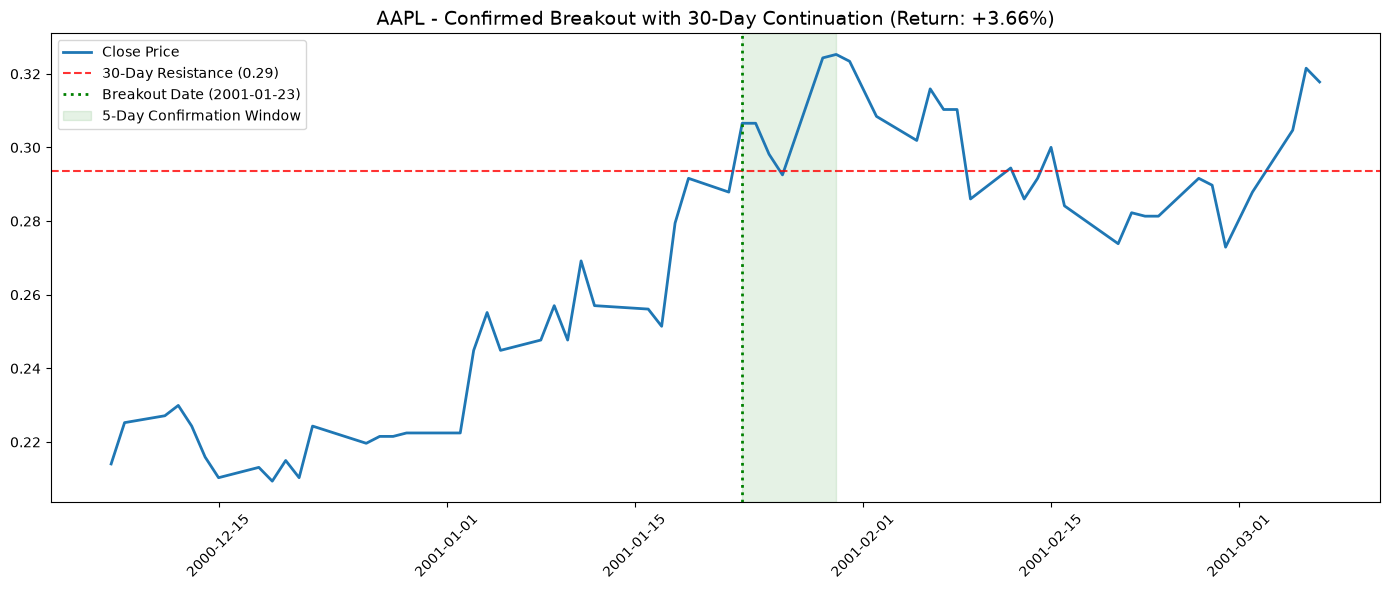

In [13]:
import matplotlib.pyplot as plt

# Select a clean breakout candidate from AAPL
sample_bo = unified_df[(unified_df["Ticker"] == "AAPL") & (unified_df["Label"] == "breakout")].iloc[5]
bo_date = sample_bo["Date"]
bo_res = sample_bo["Resistance"]

df_aapl = pd.read_csv("stock_data/AAPL.csv")
df_aapl["Date"] = pd.to_datetime(df_aapl["Date"])
idx = df_aapl.index[df_aapl["Date"] == bo_date][0]

start = max(0, idx - LOOKBACK)
end = min(len(df_aapl), idx + HORIZON_30D + 1)
chart_df = df_aapl.iloc[start:end]

fig = plt.figure(figsize=(14, 6))
plt.plot(chart_df["Date"], chart_df["Close"], label="Close Price", color="#1f77b4", linewidth=2)
plt.axhline(bo_res, linestyle="--", label=f"30-Day Resistance ({bo_res:.2f})", color="red", alpha=0.8)
plt.axvline(df_aapl.loc[idx, "Date"], linestyle=":", label=f"Breakout Date ({bo_date})", color="green", linewidth=2)
plt.axvspan(df_aapl.loc[idx, "Date"], df_aapl.loc[min(idx+CONFIRMATION_DAYS, len(df_aapl)-1), "Date"], color="green", alpha=0.1, label="5-Day Confirmation Window")

plt.title(f"AAPL - Confirmed Breakout with 30-Day Continuation (Return: {sample_bo['Return_30d_%']:+.2f}%)", fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 Visualize a Fakeout (Bull Trap) Over 30 Days
Plot a confirmed fakeout event showing how the price initially breached resistance, failed during the confirmation window, and suffered significant downward drawdown over the 30-day horizon.


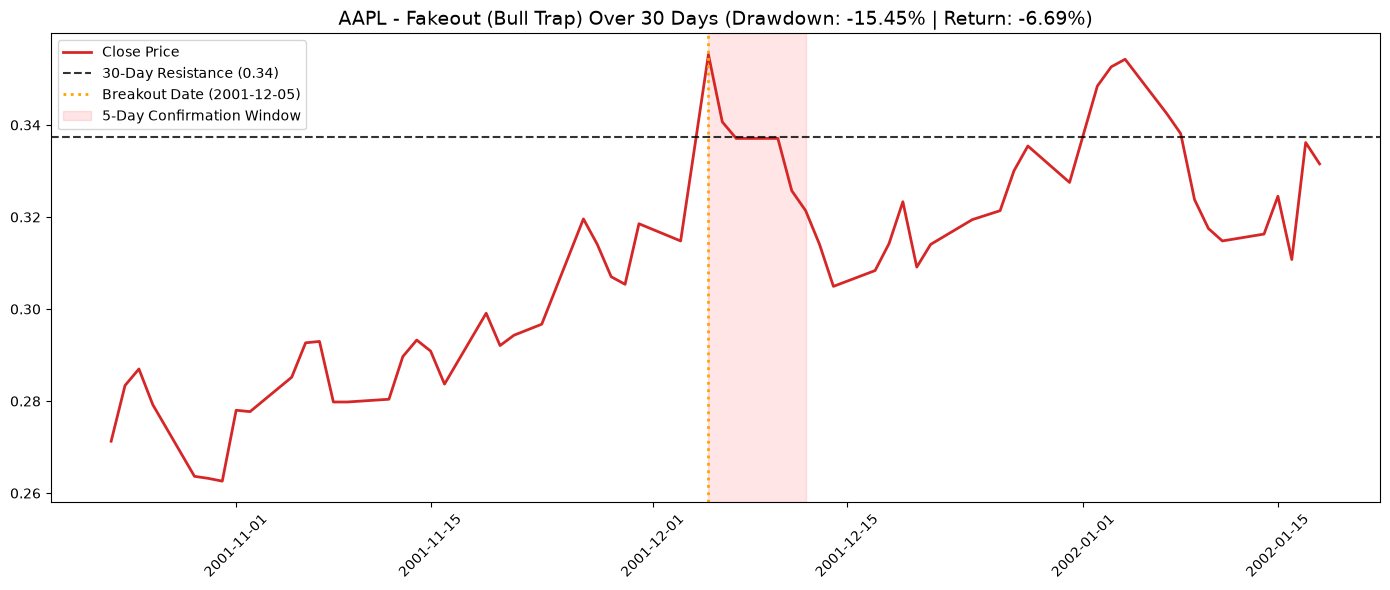

In [14]:
sample_fo = unified_df[(unified_df["Ticker"] == "AAPL") & (unified_df["Label"] == "fakeout")].iloc[0]
fo_date = sample_fo["Date"]
fo_res = sample_fo["Resistance"]

idx_fo = df_aapl.index[df_aapl["Date"] == fo_date][0]
start_fo = max(0, idx_fo - LOOKBACK)
end_fo = min(len(df_aapl), idx_fo + HORIZON_30D + 1)
chart_fo = df_aapl.iloc[start_fo:end_fo]

fig = plt.figure(figsize=(14, 6))
plt.plot(chart_fo["Date"], chart_fo["Close"], label="Close Price", color="#d62728", linewidth=2)
plt.axhline(fo_res, linestyle="--", label=f"30-Day Resistance ({fo_res:.2f})", color="black", alpha=0.8)
plt.axvline(df_aapl.loc[idx_fo, "Date"], linestyle=":", label=f"Breakout Date ({fo_date})", color="orange", linewidth=2)
plt.axvspan(df_aapl.loc[idx_fo, "Date"], df_aapl.loc[min(idx_fo+CONFIRMATION_DAYS, len(df_aapl)-1), "Date"], color="red", alpha=0.1, label="5-Day Confirmation Window")

plt.title(f"AAPL - Fakeout (Bull Trap) Over 30 Days (Drawdown: {sample_fo['Max_Drawdown_30d_%']:.2f}% | Return: {sample_fo['Return_30d_%']:+.2f}%)", fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Next Steps: Feature Engineering Roadmap

With the unified baseline dataset established in `data/unified_breakout_dataset.csv`, we are ready to engineer predictive features without modifying the baseline ground-truth labels.

### Planned Predictive Features for Next Phase:
1. **Consolidation / Volatility Metrics**:
   - Pre-breakout ATR (Average True Range) compression (Bollinger Band / Keltner Squeeze).
   - Ratio of candle range to 20-day ATR.
2. **Trend & Distance Metrics**:
   - Distance from key Moving Averages (EMA 20, SMA 50, SMA 200).
   - Rate of Change (ROC) and RSI (Relative Strength Index) leading up to breakout day.
3. **Volume Quality & Order Flow Proxies**:
   - On-Balance Volume (OBV) trend prior to breakout.
   - Accumulation/Distribution Line (A/D) slope.
4. **Candle Microstructure**:
   - Upper shadow ratio vs. Body ratio on the breakout candle.
